# Cyclone Preheater – Detecting Abnormal Operating Periods
*"how far is each signal from what is normal for this plant at this time?" 
– if one or more signals stay far from normal for many hours, that is an abnormal period.*



## 1. Data loading and cleaning

In [27]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'font.size': 10})


import os
for p in ['dataset.csv', '../data/raw/dataset.csv', '/mnt/user-data/uploads/dataset.csv']:
    if os.path.exists(p): DATA_PATH = p; break
raw = pd.read_csv(DATA_PATH)
print('Rows:', len(raw), '| Columns:', list(raw.columns))
raw.head()

Rows: 377719 | Columns: ['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']


,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,01-01-2017 00:00,867.63,910.42,-189.54,-186.04,852.13,-145.9
1,01-01-2017 00:05,879.23,918.14,-184.33,-182.1,862.53,-149.76
2,01-01-2017 00:10,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,01-01-2017 00:15,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,01-01-2017 00:20,891.66,934.26,-178.32,-173.72,876.06,-143.39


### 1.1 Timestamp problem 


In [28]:
t = raw['time'].str.replace('/', '-', regex=False)
raw['time'] = pd.to_datetime(t, format='%m-%d-%Y %H:%M')

gaps = raw['time'].diff().value_counts().head(4)
print('Time step between consecutive rows:'); print(gaps)
print('\nPeriod covered:', raw['time'].min(), '->', raw['time'].max())
      

Time step between consecutive rows:
time
0 days 00:05:00    377715
1 days 00:00:00         3
Name: count, dtype: int64

Period covered: 2017-01-01 00:00:00 -> 2020-08-07 12:15:00


### 1.2 Sensor errors: text codes and "fake" numbers
Two kinds of bad data are hiding in the sensor columns:
1. **Text codes** (`Not Connect`, `I/O Timeout`, `Configure`, `Scan Timeout`, `Comm Fail`, `Unit Down`) – communication faults. → converted to `NaN`.
2. **Fake numbers that look valid** – e.g. material temperature exactly `0`, `-185` `1375` 



In [ ]:
cols = ['Cyclone_Inlet_Gas_Temp','Cyclone_Gas_Outlet_Temp','Cyclone_Material_Temp',
        'Cyclone_Inlet_Draft','Cyclone_cone_draft','Cyclone_Outlet_Gas_draft']
short = {'Cyclone_Inlet_Gas_Temp':'inlet_T','Cyclone_Gas_Outlet_Temp':'out_T','Cyclone_Material_Temp':'mat_T',
         'Cyclone_Inlet_Draft':'in_draft','Cyclone_cone_draft':'cone_draft','Cyclone_Outlet_Gas_draft':'out_draft'}

codes = {}
for c in cols:
    num = pd.to_numeric(raw[c], errors='coerce')
    codes[c] = raw[c][num.isna()].value_counts().to_dict()
print('Text error codes per column:')
for k, v in codes.items(): print(f'  {short[k]:11s}', v)

df = raw.set_index('time')[cols].apply(pd.to_numeric, errors='coerce').rename(columns=short)
n_text = df.isna().any(axis=1).sum()


fake_zero = (df.mat_T <= 0).sum();  fake_ceiling = ((df.mat_T >= 1375) | (df.out_T >= 1375)).sum()
print(f'\nRows with a text error code : {n_text}')
print(f'Material temp <= 0           : {fake_zero}   (sensor drop-out / plant cold)')
print(f'Readings stuck at 1375 ceiling: {fake_ceiling}')

df.loc[df.mat_T <= 0, 'mat_T'] = np.nan
df.loc[df.mat_T >= 1375, 'mat_T'] = np.nan
df.loc[df.out_T >= 1375, 'out_T'] = np.nan
df.loc[df.inlet_T <= 0, 'inlet_T'] = np.nan
print('\nMissing values after cleaning:'); print(df.isna().sum().to_string())

Text error codes per column:
  inlet_T     {'Not Connect': 723, 'I/O Timeout': 470, 'Configure': 108, 'Scan Timeout': 17, 'Comm Fail': 2}
  out_T       {'Not Connect': 723, 'I/O Timeout': 470, 'Configure': 108, 'Scan Timeout': 17, 'Comm Fail': 2, 'Unit Down': 1}
  mat_T       {'Not Connect': 723, 'I/O Timeout': 470, 'Unit Down': 271, 'Configure': 108, 'Scan Timeout': 17, 'Comm Fail': 2}
  in_draft    {'Not Connect': 723, 'I/O Timeout': 470, 'Configure': 108, 'Scan Timeout': 17, 'Unit Down': 2, 'Comm Fail': 2}
  cone_draft  {'Not Connect': 723, 'I/O Timeout': 470, 'Configure': 108, 'Scan Timeout': 17, 'Comm Fail': 2}
  out_draft   {'Not Connect': 723, 'I/O Timeout': 470, 'Configure': 108, 'Scan Timeout': 17, 'Comm Fail': 2, 'Unit Down': 1}

Rows with a text error code : 1595
Material temp <= 0           : 14310   (sensor drop-out / plant cold)
Readings stuck at 1375 ceiling: 27

Missing values after cleaning:
inlet_T        1323
out_T          1345
mat_T         15904
in_draft       132

## 2. Understanding the plant (EDA)


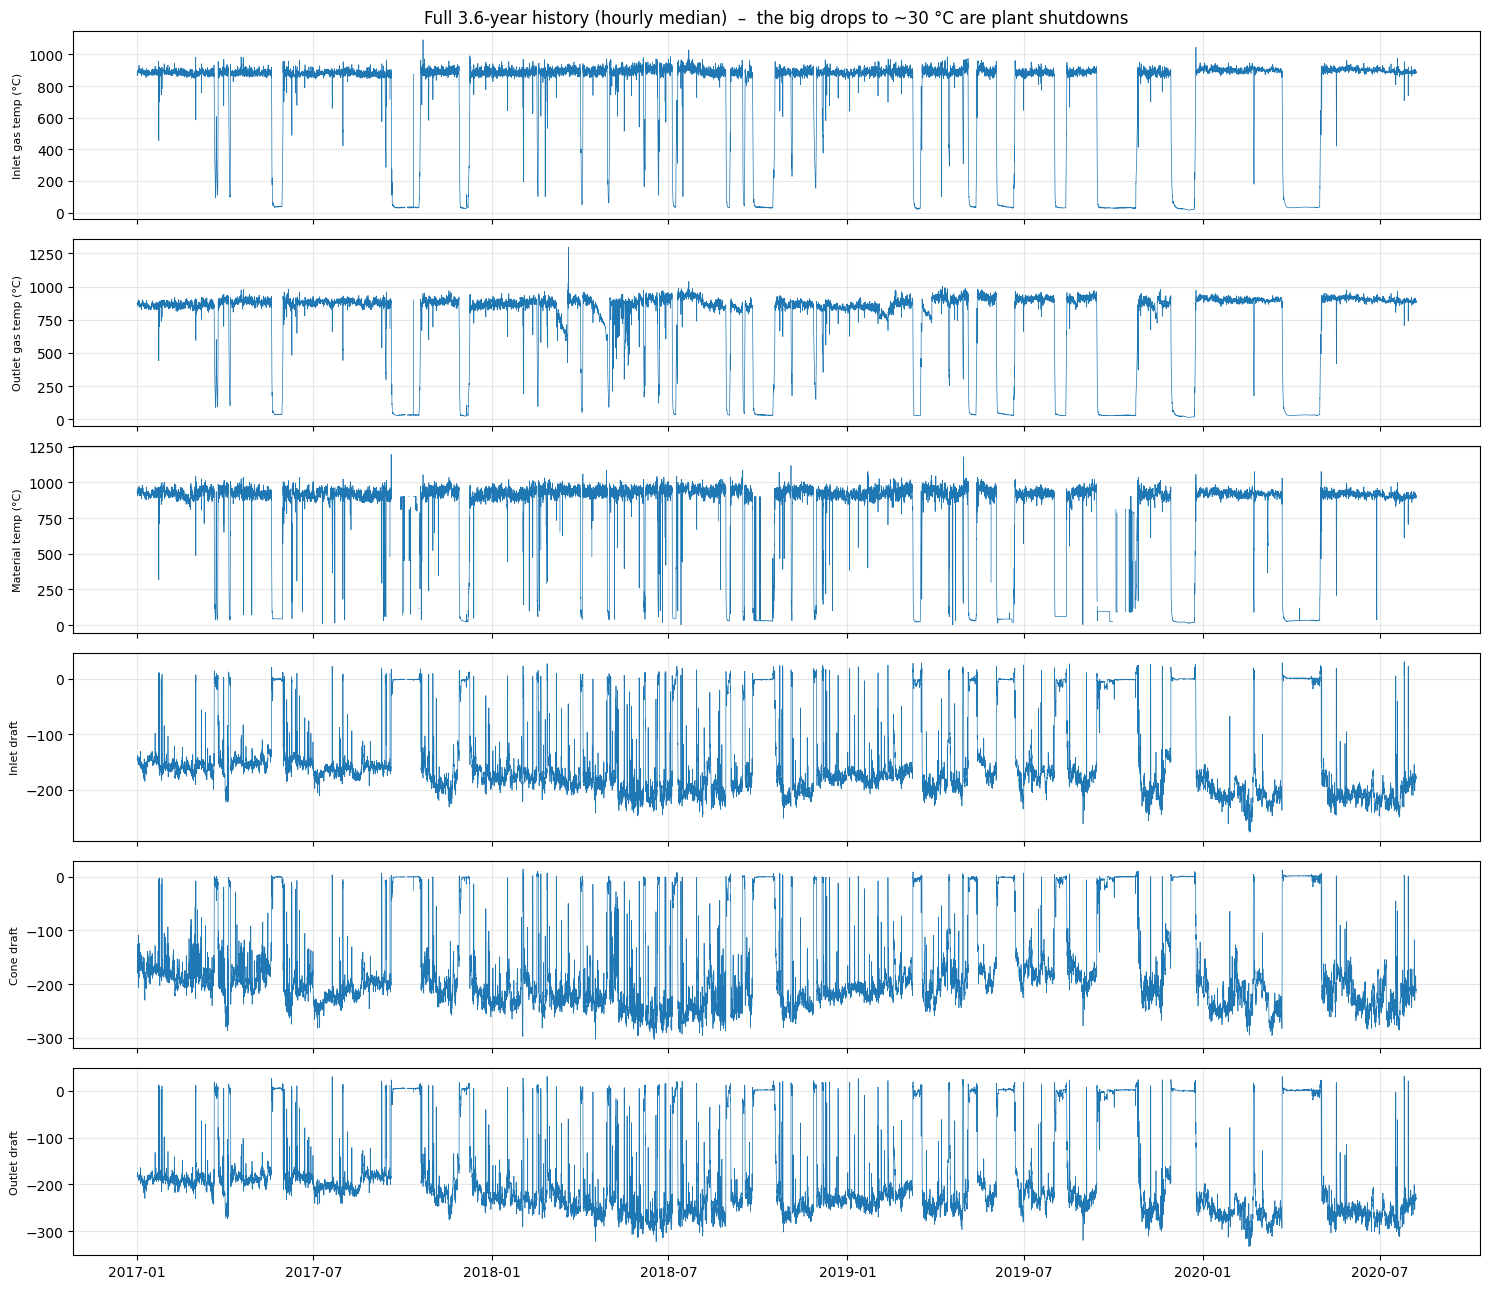

In [4]:
hourly_view = df.resample('1h').median()
fig, ax = plt.subplots(6, 1, figsize=(15, 13), sharex=True)
names = {'inlet_T':'Inlet gas temp (°C)','out_T':'Outlet gas temp (°C)','mat_T':'Material temp (°C)',
         'in_draft':'Inlet draft','cone_draft':'Cone draft','out_draft':'Outlet draft'}
for a, c in zip(ax, names):
    a.plot(hourly_view.index, hourly_view[c], lw=.5); a.set_ylabel(names[c], fontsize=8)
ax[0].set_title('Full 3.6-year history (hourly median)  –  the big drops to ~30 °C are plant shutdowns')
plt.tight_layout(); plt.show()

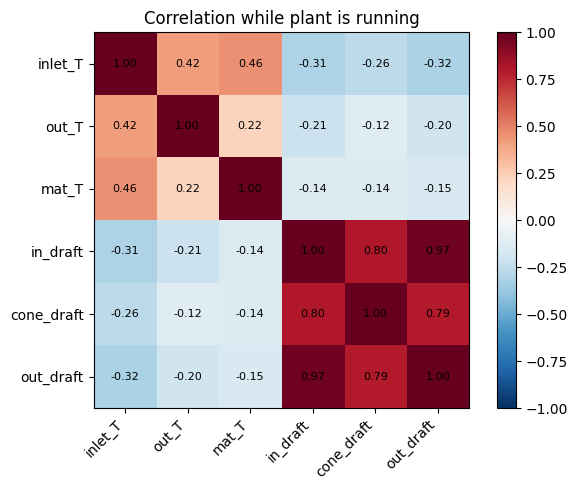

In [5]:
# Correlation of running-state data: which sensors move together?
run_tmp = df[(df.inlet_T > 700)]
corr = run_tmp.corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(6)); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(6)); ax.set_yticklabels(corr.columns); ax.grid(False)
for i in range(6):
    for j in range(6): ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); ax.set_title('Correlation while plant is running'); plt.tight_layout(); plt.show()

## 3. Running vs shutdown
We label a 5-minute record as **running** when the gas is hot (`inlet_T > 700 °C`) **and** the fan is pulling (`in_draft` and `out_draft` < −80). A 1-hour majority filter removes flicker, and the first **2 hours after every restart** are discarded because temperatures are still warming up (that is a normal transient, not a fault).

Running   : 77.7% of time
Stable    : 76.6% of time  (used for analysis)
Shutdown / warm-up: 23.4% of time  (excluded)


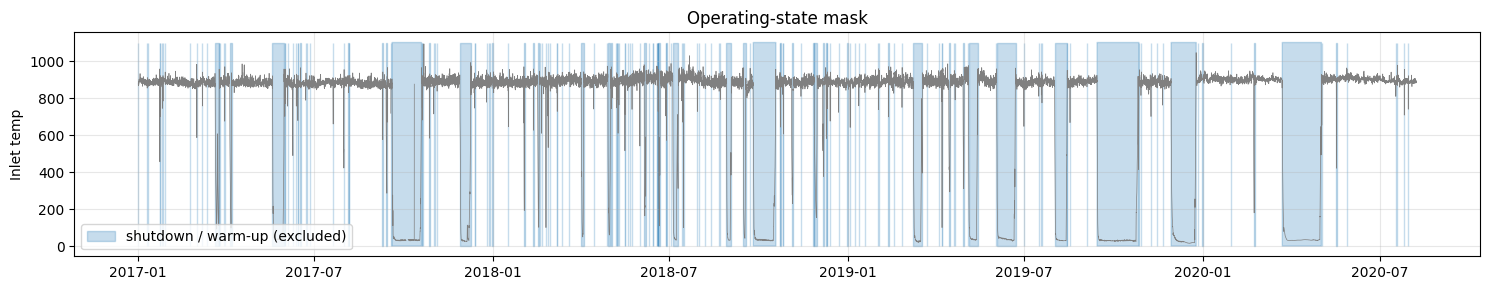

In [6]:
running = (df.inlet_T > 700) & (df.in_draft < -80) & (df.out_draft < -80)
running = running.rolling(12, center=True, min_periods=1).median().astype(bool)

block = (running != running.shift()).cumsum()
steps_since_start = running.groupby(block).cumcount()
stable = running & (steps_since_start >= 24)          # 24 x 5 min = 2 h warm-up removed

print(f'Running   : {running.mean()*100:.1f}% of time')
print(f'Stable    : {stable.mean()*100:.1f}% of time  (used for analysis)')
print(f'Shutdown / warm-up: {(~stable).mean()*100:.1f}% of time  (excluded)')

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(hourly_view.index, hourly_view.inlet_T, lw=.5, color='gray')
ax.fill_between(hourly_view.index, 0, 1100, where=~stable.resample('1h').max().reindex(hourly_view.index).fillna(False).astype(bool),
                color='tab:blue', alpha=.25, label='shutdown / warm-up (excluded)')
ax.set_ylabel('Inlet temp'); ax.legend(loc='lower left'); ax.set_title('Operating-state mask'); plt.tight_layout(); plt.show()

## 4. Feature engineering 

| Feature | Formula | What it means physically |
|---|---|---|
| `dT` | inlet_T − out_T | Heat the gas gives up in the cyclone. **Rising dT with a cold outlet** → gas short-circuiting/blocked (build-up). **Negative dT** → outlet hotter than inlet → burning inside the preheater |
| `dTm` | mat_T − out_T | Material vs gas temperature gap |
| `d_cone_in` | cone_draft − in_draft | Pressure drop inlet → cone |
| `d_out_cone` | out_draft − cone_draft | Pressure drop cone → outlet |
| `d_out_in` | out_draft − in_draft | Total pressure drop across cyclone (↑ in magnitude = blockage / restriction) |
| `*_std` | rolling std of drafts and temps over 1 h | Draft **instability** (surging/plugging) |



In [7]:
s = df[stable].copy()
s['dT']         = s.inlet_T - s.out_T
s['dTm']        = s.mat_T   - s.out_T
s['d_cone_in']  = s.cone_draft - s.in_draft
s['d_out_cone'] = s.out_draft  - s.cone_draft
s['d_out_in']   = s.out_draft  - s.in_draft

level_cols = ['inlet_T','out_T','mat_T','dT','dTm','d_cone_in','d_out_cone','d_out_in']
std_cols   = ['in_draft','cone_draft','out_draft','out_T']

g = s.resample('1h')
H = g[level_cols].median()
H = H.join(g[std_cols].std().add_suffix('_std'))
H['n'] = g['inlet_T'].count()
H = H[H.n >= 8].drop(columns='n').dropna()
print('Hourly feature table:', H.shape)
H.describe().T.round(1)

Hourly feature table: (24048, 12)


,count,mean,std,min,25%,50%,75%,max
inlet_T,24048.0,890.7,17.5,800.0,879.3,889.6,901.4,1092.3
out_T,24048.0,878.5,45.8,213.4,860.3,885.1,904.6,1296.5
mat_T,24048.0,924.5,53.6,1.1,907.8,926.6,946.1,1075.9
dT,24048.0,12.7,43.1,-356.9,-8.8,2.9,25.5,660.7
dTm,24048.0,46.1,65.5,-919.5,20.3,39.7,63.9,707.7
d_cone_in,24048.0,-29.2,23.1,-100.6,-44.7,-33.3,-15.8,122.0
d_out_cone,24048.0,-18.3,25.6,-180.3,-33.5,-16.5,-0.9,55.8
d_out_in,24048.0,-47.5,11.7,-88.2,-55.4,-49.6,-39.3,-3.8
in_draft_std,24048.0,6.1,5.0,0.0,4.0,5.1,6.6,99.4
cone_draft_std,24048.0,7.9,6.5,0.0,5.1,6.5,8.6,249.9


## 5. Method: "how far from normal?" (z-score)
For each hourly feature we compute

**z = (value − normal value) / typical spread**



* **Two passes:** pass 1 finds obvious alarms; pass 2 recomputes "normal" from the *non-alarm hours only*, so long faults cannot drag the normal value towards themselves and hide.

| Feature | Direction that is abnormal | Physical meaning |
|---|---|---|
| `dT` (inlet − outlet gas temp) | high **or** low | high = outlet unusually cold (restricted gas path / build-up); low = outlet unusually hot |
| `out_T` (outlet gas temp) | high or low | same story seen from the outlet sensor |
| `d_out_in` (total pressure drop) | high or low | resistance of the cyclone changed |
| `cone_draft_std`, `in_draft_std`, `out_draft_std` | **high only** | pressure surging / unstable flow |

In [ ]:
feats     = ['dT', 'out_T', 'd_out_in', 'cone_draft_std', 'in_draft_std', 'out_draft_std']
one_sided = ['cone_draft_std', 'in_draft_std', 'out_draft_std']       # only 'too high' is a problem

def robust_z(H, healthy):
    """z-score of every feature vs its local normal (45-day rolling median of healthy hours)."""
    Z, DEV = pd.DataFrame(index=H.index), pd.DataFrame(index=H.index)
    for f in feats:
        normal = (H[f].where(healthy).rolling('45D', center=True, min_periods=50).median()
                    .reindex(H.index).interpolate(limit_direction='both'))
        dev = H[f] - normal
        spread = 1.4826 * dev[healthy].abs().median()          # 'standard deviation'
        Z[f], DEV[f] = dev / spread, dev
    return Z, DEV, spread

def alarm_table(Zs, thr):
    """True where a (smoothed) feature is beyond the threshold in its abnormal direction."""
    A = pd.DataFrame(index=Zs.index)
    for f in feats:
        A[f] = (Zs[f] > thr) if f in one_sided else (Zs[f].abs() > thr)
    return A

THR = 5            
healthy = pd.Series(True, index=H.index)
for p in range(2):                                                # two passes
    Z, DEV, _ = robust_z(H, healthy)
    Zs = Z.rolling('6h', min_periods=3).median()                  # 6-hour median: kills one-hour spikes
    A  = alarm_table(Zs, THR)
    healthy = ~A.any(axis=1)
    print(f'pass {p+1}: hours with at least one feature in alarm = {A.any(axis=1).sum()}')
H['alarm'] = A.any(axis=1)

pass 1: hours with at least one feature in alarm = 1341
pass 2: hours with at least one feature in alarm = 1487


**What this looks like for one feature (ΔT, 2018):** the grey band is the normal range; the red parts are where ΔT leaves it.

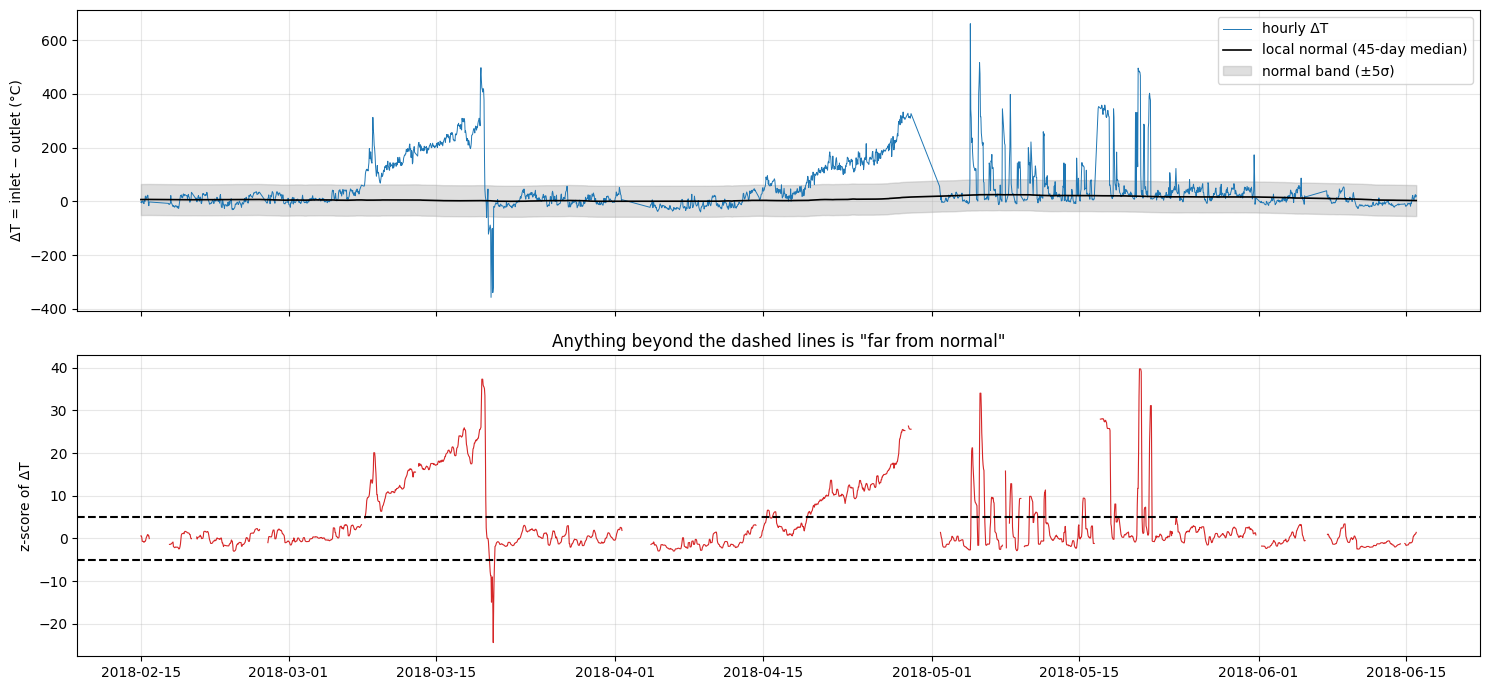

In [9]:
sub = slice('2018-02-15', '2018-06-15')
normal = H.dT.where(healthy).rolling('45D', center=True, min_periods=50).median().reindex(H.index).interpolate(limit_direction='both')
spread = 1.4826 * (H.dT - normal)[healthy].abs().median()
fig, ax = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax[0].plot(H.dT[sub].index, H.dT[sub], lw=.7, label='hourly ΔT')
ax[0].plot(normal[sub].index, normal[sub], 'k', lw=1.2, label='local normal (45-day median)')
ax[0].fill_between(normal[sub].index, (normal-THR*spread)[sub], (normal+THR*spread)[sub], color='gray', alpha=.25, label=f'normal band (±{THR}σ)')
ax[0].set_ylabel('ΔT = inlet − outlet (°C)'); ax[0].legend(loc='upper right')
ax[1].plot(Zs.dT[sub].index, Zs.dT[sub], c='tab:red', lw=.8); ax[1].axhline(THR, c='k', ls='--'); ax[1].axhline(-THR, c='k', ls='--')
ax[1].set_ylabel('z-score of ΔT'); ax[1].set_title('Anything beyond the dashed lines is "far from normal"')
plt.tight_layout(); plt.show()

## 6. From alarm hours to abnormal *periods*
A single noisy hour is not an operating problem. So:
1. A feature must be out of range on its **6-hour median** (already applied above).
2. Alarms that are **less than 12 h apart are merged** (one fault, not many..).
3. A period must last **at least 12 h** to be reported.

The threshold `THR = 5` is a choice – so we also test how sensitive .

Abnormal periods found with THR = 5 : 22


,periods,abnormal_hours
threshold,,
3,66,3319
4,32,1924
5,22,1479
6,18,1229
8,11,941
10,10,643


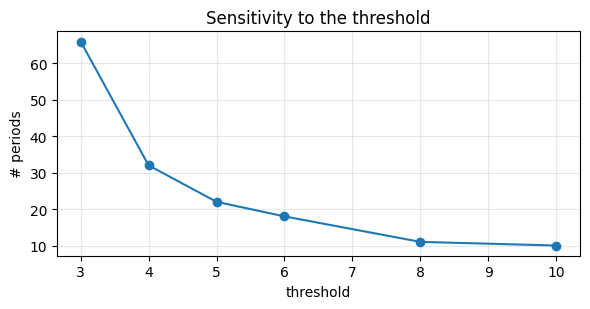

In [10]:
def build_events(alarm, merge_gap='12h', min_len='12h'):
    idx = alarm.index[alarm]; ev = []; start = end = None
    for t_ in idx:
        if start is None: start = end = t_
        elif t_ - end <= pd.Timedelta(merge_gap): end = t_
        else: ev.append((start, end)); start = end = t_
    if start is not None: ev.append((start, end))
    return [(a, b) for a, b in ev if b - a >= pd.Timedelta(min_len)]

events = build_events(H.alarm)
print('Abnormal periods found with THR =', THR, ':', len(events))

# Sensitivity: does the answer collapse if we change the threshold?
rows = []
for thr in [3, 4, 5, 6, 8, 10]:
    ev_ = build_events(alarm_table(Zs, thr).any(axis=1))
    rows.append((thr, len(ev_), int(sum((b-a)/pd.Timedelta('1h')+1 for a, b in ev_))))
sens = pd.DataFrame(rows, columns=['threshold','periods','abnormal_hours']).set_index('threshold')
display(sens)
fig, ax = plt.subplots(figsize=(6, 3.2)); sens.periods.plot(marker='o', ax=ax); ax.set_ylabel('# periods'); ax.set_title('Sensitivity to the threshold')
plt.tight_layout(); plt.show()

Stricter thresholds report fewer, but the **biggest periods stay** – they are not borderline cases. The number of marginal periods is what changes.

## 7. Naming the cause of each period
For each period we count **how many hours each feature was out of range**; the feature that is out of range the longest is the *main signal*. That directly gives the reason:

| Main signal | Type | Interpretation |
|---|---|---|
| ΔT too high (or outlet too cold) | **A – Build-up / blockage** | Hot gas no longer reaches the outlet normally: gas path restricted, coating inside cyclone/riser |
| ΔT too low (or outlet too hot) | **B – Outlet over-temperature** | Fuel/volatiles burning inside the preheater (after-burning) or false air |
| any draft std too high | **C – Draft instability** | Pressure surging, typical of intermittent plugging |
| total pressure drop out of range | **D – Pressure-drop change** | Resistance of the cyclone changed; weaker evidence, treat as watch-list |

In [11]:
rows = []
for a, b in events:
    w_alarm = A.loc[a:b]; w_z = Zs.loc[a:b]; w = H.loc[a:b]
    hours_out = w_alarm.sum()                           # hours each feature was out of range
    main = hours_out.idxmax()
    direction = np.sign(w_z[main].median())
    if   main == 'dT'  or main == 'out_T':
        high_dT = (np.sign(w_z['dT'].median()) > 0) if main == 'dT' else (np.sign(w_z['out_T'].median()) < 0)
        typ = 'A: Build-up / blockage' if high_dT else 'B: Outlet over-temperature'
    elif main in one_sided: typ = 'C: Draft instability'
    else:                   typ = 'D: Pressure-drop change'
    rows.append(dict(start=a, end=b, hours=(b-a)/pd.Timedelta('1h')+1, type=typ, main_signal=main,
                     peak_z=w_z[main].abs().max(),
                     dT_vs_normal=DEV.dT.loc[a:b].median(), outlet_vs_normal=DEV.out_T.loc[a:b].median(),
                     cone_draft_std=w.cone_draft_std.median()))
EV = pd.DataFrame(rows); EV['hours'] = EV.hours.round(0)
pd.set_option('display.width', 220)
EV.round(1)

,start,end,hours,type,main_signal,peak_z,dT_vs_normal,outlet_vs_normal,cone_draft_std
0,2017-02-24 15:00:00,2017-02-25 22:00:00,32.0,C: Draft instability,cone_draft_std,23.8,-15.9,8.0,30.8
1,2017-02-27 01:00:00,2017-03-01 15:00:00,63.0,C: Draft instability,cone_draft_std,9.3,-1.2,-9.9,18.4
2,2017-03-29 21:00:00,2017-03-31 18:00:00,46.0,C: Draft instability,cone_draft_std,11.0,-8.8,7.2,19.2
3,2017-10-25 11:00:00,2017-10-26 03:00:00,17.0,C: Draft instability,cone_draft_std,6.3,1.3,-5.7,16.0
4,2018-01-27 08:00:00,2018-01-28 15:00:00,32.0,D: Pressure-drop change,d_out_in,6.5,15.7,-24.4,5.8
5,2018-03-08 07:00:00,2018-03-20 13:00:00,295.0,A: Build-up / blockage,dT,37.3,195.3,-186.1,7.5
6,2018-04-15 09:00:00,2018-04-16 20:00:00,36.0,A: Build-up / blockage,dT,6.6,54.2,-50.4,8.1
7,2018-04-19 05:00:00,2018-04-29 01:00:00,237.0,A: Build-up / blockage,dT,26.3,139.9,-142.3,7.8
8,2018-05-04 18:00:00,2018-05-07 11:00:00,66.0,A: Build-up / blockage,dT,34.0,59.0,-65.7,12.1
9,2018-05-08 00:00:00,2018-05-08 15:00:00,16.0,A: Build-up / blockage,dT,15.8,31.0,-43.1,10.9


## 8. Visual results

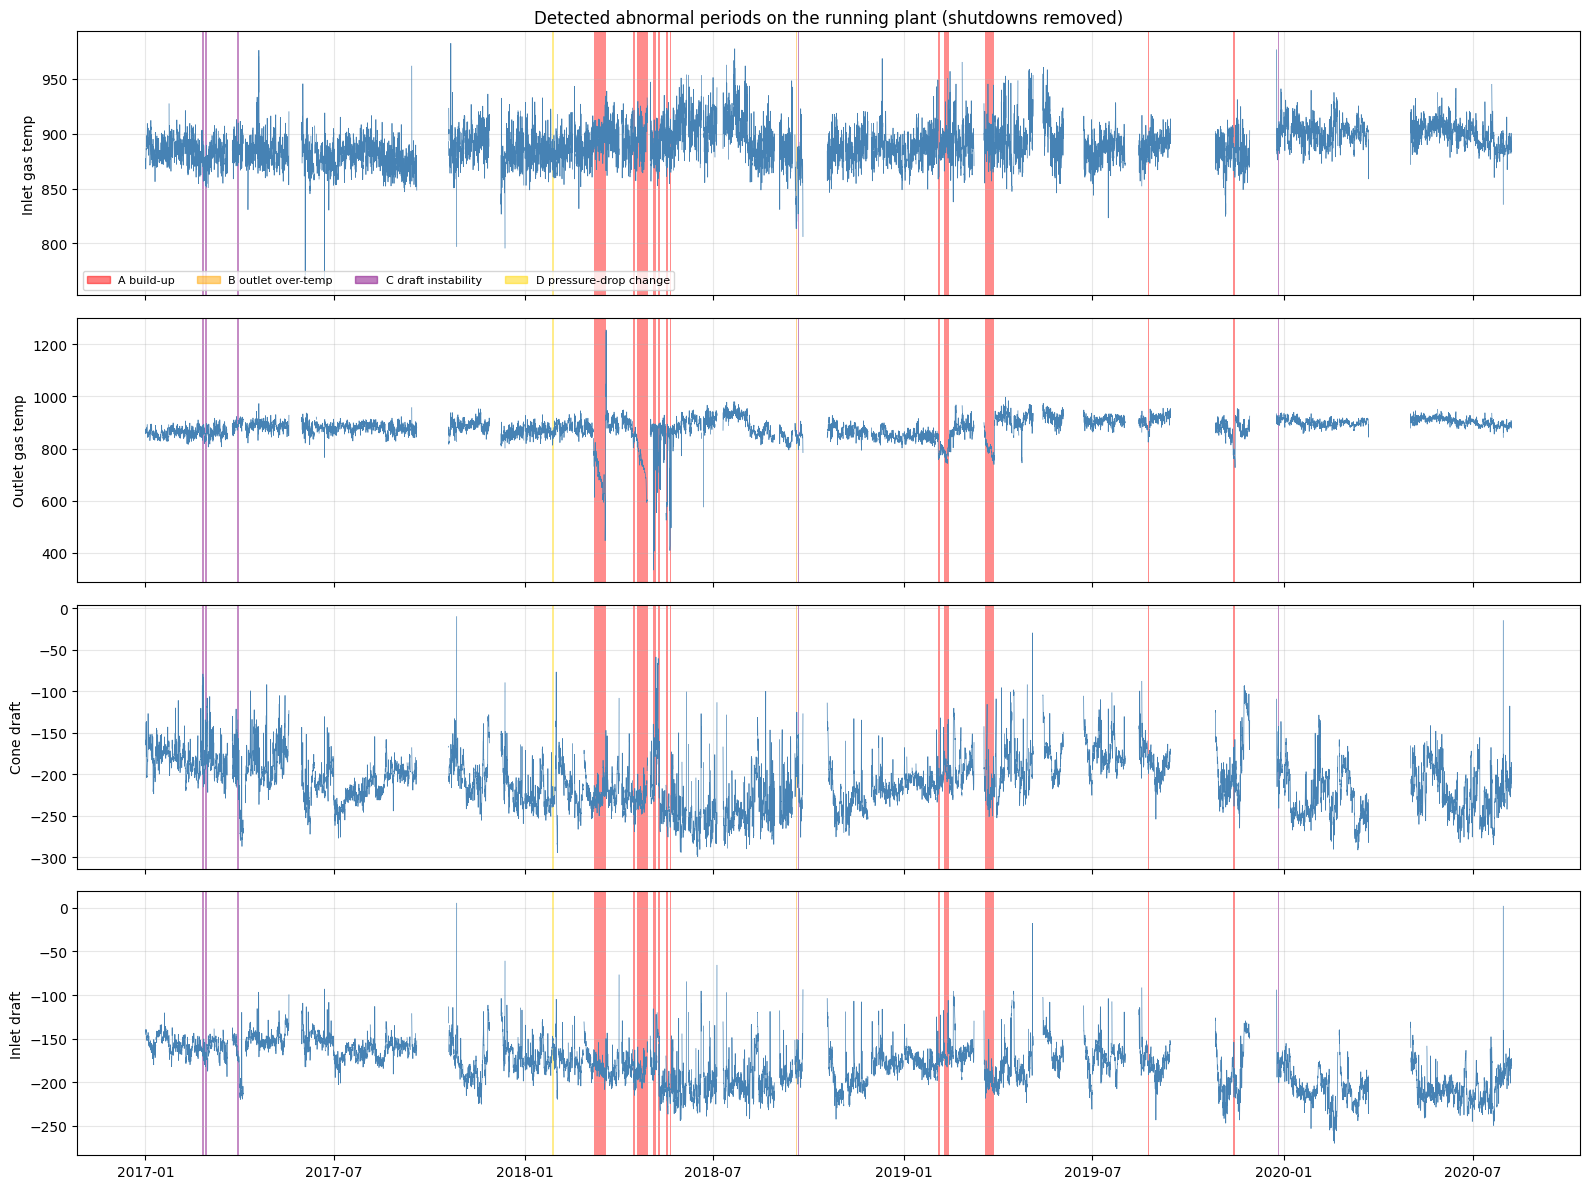

In [29]:
colors = {'A':'red', 'B':'orange', 'C':'purple', 'D':'gold'}
d2 = df[stable].resample('2h').median()
fig, ax = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for a_, k, lab in zip(ax, ['inlet_T','out_T','cone_draft','in_draft'],
                      ['Inlet gas temp','Outlet gas temp','Cone draft','Inlet draft']):
    a_.plot(d2.index, d2[k], lw=.5, c='steelblue'); a_.set_ylabel(lab)
    for _, r in EV.iterrows(): a_.axvspan(r.start, r.end, color=colors[r.type[0]], alpha=.45, lw=0)
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color='red', alpha=.5, label='A build-up'), Patch(color='orange', alpha=.5, label='B outlet over-temp'),
                      Patch(color='purple', alpha=.5, label='C draft instability'), Patch(color='gold', alpha=.5, label='D pressure-drop change')],
             loc='lower left', ncol=4, fontsize=8)
ax[0].set_title('Detected abnormal periods on the running plant (shutdowns removed)')
plt.tight_layout(); plt.show()

,periods,total_hours,longest_h
type,,,
A: Build-up / blockage,14,1242.0,295.0
B: Outlet over-temperature,1,18.0,18.0
C: Draft instability,6,187.0,63.0
D: Pressure-drop change,1,32.0,32.0


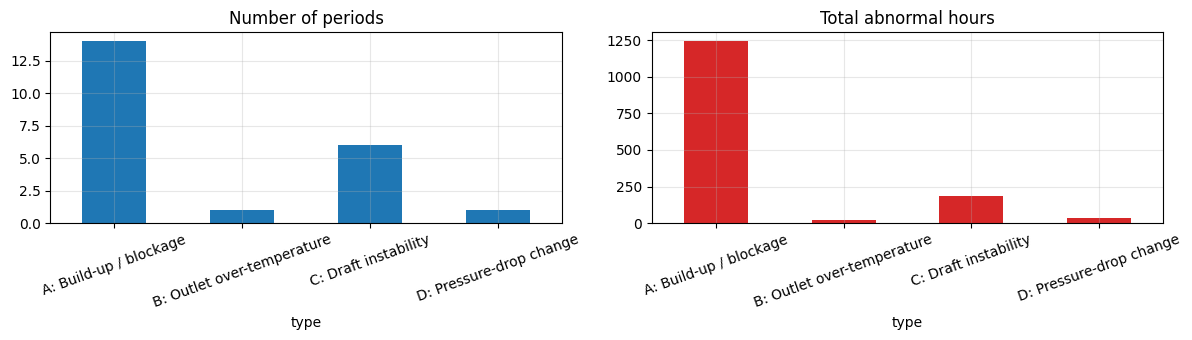

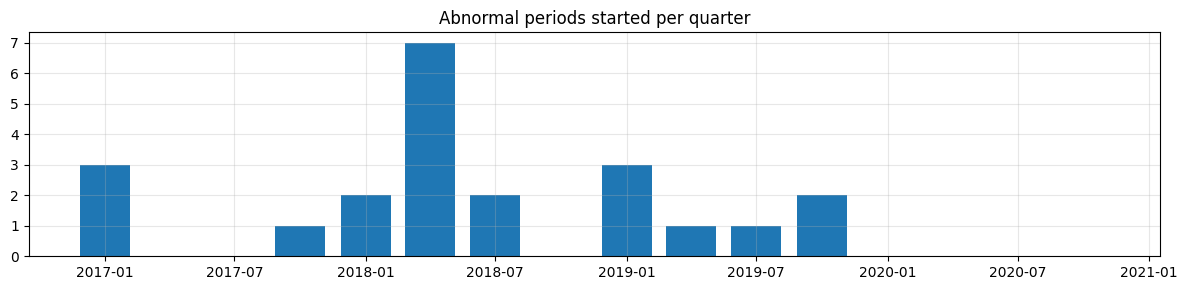

In [30]:
summ = EV.groupby('type').agg(periods=('hours','size'), total_hours=('hours','sum'), longest_h=('hours','max'))
display(summ)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
summ.periods.plot.bar(ax=ax[0], color='tab:blue'); ax[0].set_title('Number of periods'); ax[0].tick_params(axis='x', rotation=20)
summ.total_hours.plot.bar(ax=ax[1], color='tab:red'); ax[1].set_title('Total abnormal hours'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

cnt = pd.Series(1, index=EV.start).resample('QS').sum().reindex(pd.date_range('2017-01-01', '2020-10-01', freq='QS'), fill_value=0)
fig, ax = plt.subplots(figsize=(12, 3)); ax.bar(cnt.index, cnt.values, width=70)
ax.set_title('Abnormal periods started per quarter'); plt.tight_layout(); plt.show()

## 9. Final table of abnormal periods

In [31]:
final = EV[['start','end','hours','type','main_signal','peak_z','dT_vs_normal','outlet_vs_normal']].round(1)
final.to_csv('abnormal_periods.csv', index=False)
final

,start,end,hours,type,main_signal,peak_z,dT_vs_normal,outlet_vs_normal
0,2017-02-24 15:00:00,2017-02-25 22:00:00,32.0,C: Draft instability,cone_draft_std,23.8,-15.9,8.0
1,2017-02-27 01:00:00,2017-03-01 15:00:00,63.0,C: Draft instability,cone_draft_std,9.3,-1.2,-9.9
2,2017-03-29 21:00:00,2017-03-31 18:00:00,46.0,C: Draft instability,cone_draft_std,11.0,-8.8,7.2
3,2017-10-25 11:00:00,2017-10-26 03:00:00,17.0,C: Draft instability,cone_draft_std,6.3,1.3,-5.7
4,2018-01-27 08:00:00,2018-01-28 15:00:00,32.0,D: Pressure-drop change,d_out_in,6.5,15.7,-24.4
5,2018-03-08 07:00:00,2018-03-20 13:00:00,295.0,A: Build-up / blockage,dT,37.3,195.3,-186.1
6,2018-04-15 09:00:00,2018-04-16 20:00:00,36.0,A: Build-up / blockage,dT,6.6,54.2,-50.4
7,2018-04-19 05:00:00,2018-04-29 01:00:00,237.0,A: Build-up / blockage,dT,26.3,139.9,-142.3
8,2018-05-04 18:00:00,2018-05-07 11:00:00,66.0,A: Build-up / blockage,dT,34.0,59.0,-65.7
9,2018-05-08 00:00:00,2018-05-08 15:00:00,16.0,A: Build-up / blockage,dT,15.8,31.0,-43.1
